# Import Libraries

In [1]:
import pandas as pd
from pathlib import Path
from pprint import pprint
import SimpleITK as sitk
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap, BoundaryNorm

In [2]:
DATA_DIR = Path("../../dataset/lndb/data")
MASK_DIR = Path("../../dataset/lndb/masks")

# Load trainNodules_gt_clean.csv

In [3]:
# Read the CSV file into a pandas DataFrame
df = pd.read_csv("../../dataset/_lndb/000_metadata/trainset_csv/trainNodules_gt_clean.csv")

# Display basic information about the DataFrame
print(f"{'='*20} trainNodules_gt_clean.csv Info {'='*20}")
df.info()

# Display the first five rows of the DataFrame
print(f"\n{'='*20} Top 5 Rows of trainNodules_gt_clean.csv {'='*20}")
display(df.head())

==================== trainNodules_gt_clean.csv Info ====================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lndbid        583 non-null    int64  
 1   radid         583 non-null    object 
 2   radfindingid  583 non-null    object 
 3   findingid     583 non-null    int64  
 4   agrlevel      583 non-null    int64  
 5   malignancy    583 non-null    float64
 6   category      583 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 32.0+ KB

==================== Top 5 Rows of trainNodules_gt_clean.csv ====================


,lndbid,radid,radfindingid,findingid,agrlevel,malignancy,category
0,1,"1,2,3","1,1,1",1,3,2.0,benign
1,1,1,2,2,1,2.0,benign
2,2,"1,2,3","1,1,3",1,3,1.0,benign
3,2,"1,3","2,2",2,2,1.0,benign
4,2,"1,3","3,5",3,2,2.5,benign


# Collect Scan Metadata

In [4]:
def prepare_scan_data(row):
    """
    Prepare CT scan and annotation metadata for a single finding.
    """

    # Retrieve scan and finding identifiers
    lndb_id = row["lndbid"]
    finding_id = row["findingid"]
    label = row["category"]

    # Construct CT image path and load image metadata
    ct_path = DATA_DIR / f"LNDb-{lndb_id:04d}.mhd"
    ct_image = sitk.ReadImage(ct_path)

    # Extract CT image metadata
    ct_size = ct_image.GetSize()
    ct_spacing = ct_image.GetSpacing()
    ct_origin = ct_image.GetOrigin()
    ct_direction = ct_image.GetDirection()

    # Parse radiologist IDs
    rad_ids = [
        int(idx.strip())
        for idx in str(row["radid"]).split(",")
    ]

    # Parse finding IDs assigned by each radiologist
    rad_finding_ids = [
        int(idx.strip())
        for idx in str(row["radfindingid"]).split(",")
    ]

    # Store metadata for each radiologist annotation
    radiologists = []

    for rad_id, rad_finding_id in zip(rad_ids, rad_finding_ids):
        # Construct mask path and load mask metadata
        mask_path = MASK_DIR / f"LNDb-{lndb_id:04d}_rad{rad_id}.mhd"
        mask_image = sitk.ReadImage(mask_path)

        # Save radiologist-specific information
        radiologists.append({
            "radid": rad_id,
            "radfindingid": rad_finding_id,
            "mask_path": mask_path,
            "size": mask_image.GetSize(),
            "spacing": mask_image.GetSpacing(),
            "origin": mask_image.GetOrigin(),
            "direction": mask_image.GetDirection()
        })

    # Return all metadata for this finding
    return {
        "lndb_id": lndb_id,
        "finding_id": finding_id,
        "label": label, 
        "ct_path": ct_path,
        "ct_size": ct_size,
        "ct_spacing": ct_spacing,
        "ct_origin": ct_origin,
        "ct_direction": ct_direction,
        "radiologists": radiologists
    }

In [5]:
# Prepare metadata for the first finding (example)
scans = []

for _, row in df.iterrows():
    scans.append(prepare_scan_data(row))
    break

# Display the collected metadata
scan = scans[0]
pprint(scan)

{'ct_direction': (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0),
 'ct_origin': (-158.1962890625, -309.1962890625, -297.5),
 'ct_path': WindowsPath('../../dataset/lndb/data/LNDb-0001.mhd'),
 'ct_size': (512, 512, 328),
 'ct_spacing': (0.607421875, 0.607421875, 1.0),
 'finding_id': 1,
 'label': 'benign',
 'lndb_id': 1,
 'radiologists': [{'direction': (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0),
                   'mask_path': WindowsPath('../../dataset/lndb/masks/LNDb-0001_rad1.mhd'),
                   'origin': (-158.1962890625, -309.1962890625, -297.5),
                   'radfindingid': 1,
                   'radid': 1,
                   'size': (512, 512, 328),
                   'spacing': (0.607421875, 0.607421875, 1.0)},
                  {'direction': (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0),
                   'mask_path': WindowsPath('../../dataset/lndb/masks/LNDb-0001_rad2.mhd'),
                   'origin': (-158.1962890625, -309.1962890625, -297.5),
                 

# Verify Scan Metadata

In [6]:
def verify_scan_metadata(scan):
    """
    Verify that all radiologist masks have the same image geometry
    as the corresponding CT scan.
    """

    for radiologist in scan["radiologists"]:
        # Verify image size
        if scan["ct_size"] != radiologist["size"]:
            raise ValueError(
                f"Size mismatch "
                f"(LNDb-{scan['lndb_id']:04d}, "
                f"Radiologist {radiologist['radid']}): "
                f"CT={scan['ct_size']}, "
                f"Mask={radiologist['size']}"
            )

        # Verify voxel spacing
        if scan["ct_spacing"] != radiologist["spacing"]:
            raise ValueError(
                f"Spacing mismatch "
                f"(LNDb-{scan['lndb_id']:04d}, "
                f"Radiologist {radiologist['radid']}): "
                f"CT={scan['ct_spacing']}, "
                f"Mask={radiologist['spacing']}"
            )

        # Verify image origin
        if scan["ct_origin"] != radiologist["origin"]:
            raise ValueError(
                f"Origin mismatch "
                f"(LNDb-{scan['lndb_id']:04d}, "
                f"Radiologist {radiologist['radid']}): "
                f"CT={scan['ct_origin']}, "
                f"Mask={radiologist['origin']}"
            )

        # Verify image direction
        if scan["ct_direction"] != radiologist["direction"]:
            raise ValueError(
                f"Direction mismatch "
                f"(LNDb-{scan['lndb_id']:04d}, "
                f"Radiologist {radiologist['radid']}): "
                f"CT={scan['ct_direction']}, "
                f"Mask={radiologist['direction']}"
            )

    return True

In [7]:
verify_scan_metadata(scan)
print("Metadata verification passed.")

Metadata verification passed.


# Load CT and Masks

In [8]:
def load_scan(scan):
    """
    Load CT volume and extract binary masks for each radiologist annotation.
    """

    # Load CT volume
    ct_image = sitk.ReadImage(scan["ct_path"])
    ct_volume = sitk.GetArrayFromImage(ct_image)

    radiologists = []

    for rad in scan["radiologists"]:
        # Load mask volume
        mask_image = sitk.ReadImage(rad["mask_path"])
        mask_volume = sitk.GetArrayFromImage(mask_image)

        # Extract binary mask for the target nodule
        mask_nodule = (mask_volume == rad["radfindingid"])

        # Find slices containing the selected rad finding id
        nodule_slices = np.where(
            np.any(mask_volume == rad["radfindingid"], axis=(1, 2))
            )[0]
        
        radiologists.append({
            **rad,
            "nodule_slices": nodule_slices,
            "mask_nodule": mask_nodule
        })

    return {
        **scan,
        "ct_volume": ct_volume,
        "radiologists": radiologists
    }

In [9]:
scan = load_scan(scan)

# Visualize CT & Mask Slices Containing The Selected Rad Finding Id

In [10]:
def show_ct_mask_overlay(
    ct_volume,
    mask_volume,
    slices,
    bbox=None,
    n_columns=5,
    figsize_per_subplot=3,
    mask_cmap="autumn",
    mask_alpha=0.7,
    vmin=0,
    vmax=None,
):
    """
    Display CT slices with a mask overlay and an optional bounding box.
    """

    # Exit if there are no slices to visualize.
    if len(slices) == 0:
        print("No slices to display.")
        return

    # Use the maximum mask value if not specified.
    if vmax is None:
        vmax = mask_volume.max()

    # Compute subplot layout.
    n_rows = math.ceil(len(slices) / n_columns)

    # Create figure.
    fig, axes = plt.subplots(
        n_rows,
        n_columns,
        figsize=(
            n_columns * figsize_per_subplot,
            n_rows * figsize_per_subplot,
        ),
    )

    # Flatten axes for easier iteration.
    axes = np.atleast_1d(axes).flatten()

    # Check whether a valid bounding box is provided.
    draw_bbox = (
        bbox is not None
        and isinstance(bbox, dict)
        and all(
            key in bbox
            for key in (
                "xmin",
                "xmax",
                "ymin",
                "ymax",
                "zmin",
                "zmax",
            )
        )
    )

    # Display each slice.
    for ax, slice_idx in zip(axes, slices):
        ct_slice = ct_volume[slice_idx]
        mask_slice = mask_volume[slice_idx]

        # Display CT image.
        ax.imshow(
            ct_slice,
            cmap="gray",
        )

        # Overlay mask.
        ax.imshow(
            np.ma.masked_where(mask_slice == 0, mask_slice),
            cmap=mask_cmap,
            alpha=mask_alpha,
            interpolation="none",
            vmin=vmin,
            vmax=vmax,
        )

        # Draw bounding box if available.
        if draw_bbox and bbox["zmin"] <= slice_idx <= bbox["zmax"]:
            rect = Rectangle(
                (bbox["xmin"], bbox["ymin"]),
                bbox["xmax"] - bbox["xmin"],
                bbox["ymax"] - bbox["ymin"],
                linewidth=2,
                edgecolor="lime",
                facecolor="none",
            )
            ax.add_patch(rect)

        ax.set_title(f"Slice {slice_idx}")
        ax.axis("off")

    # Hide unused subplot cells.
    for ax in axes[len(slices):]:
        ax.axis("off")

    # Add colorbar for non-binary masks.
    if vmax > 1:
        cbar = fig.colorbar(
            axes[0].images[-1],
            ax=axes.tolist(),
            shrink=0.85,
            pad=0.02,
        )
        cbar.set_label("Agreement")

    # Adjust subplot spacing.
    plt.tight_layout(
        rect=[0, 0, 1, 0.95],
        w_pad=1.0,
        h_pad=1.5,
    )

    # Display figure.
    plt.show()

==================== Radiologist 1 ====================


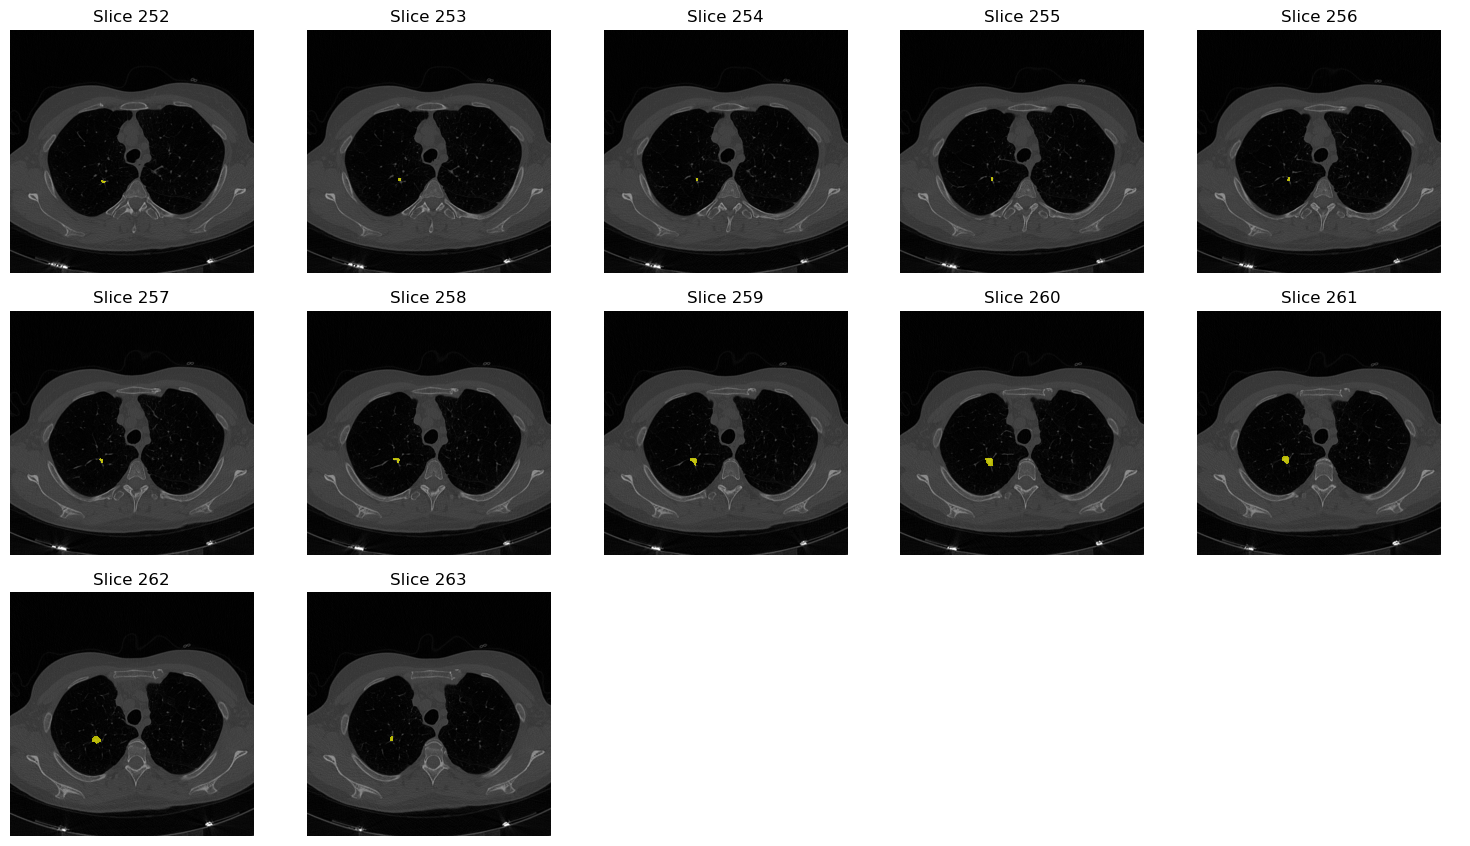

==================== Radiologist 2 ====================


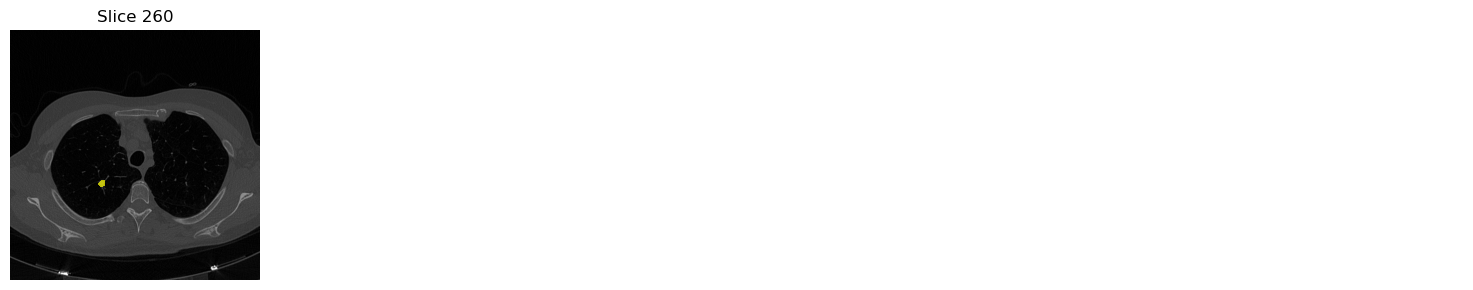

==================== Radiologist 3 ====================


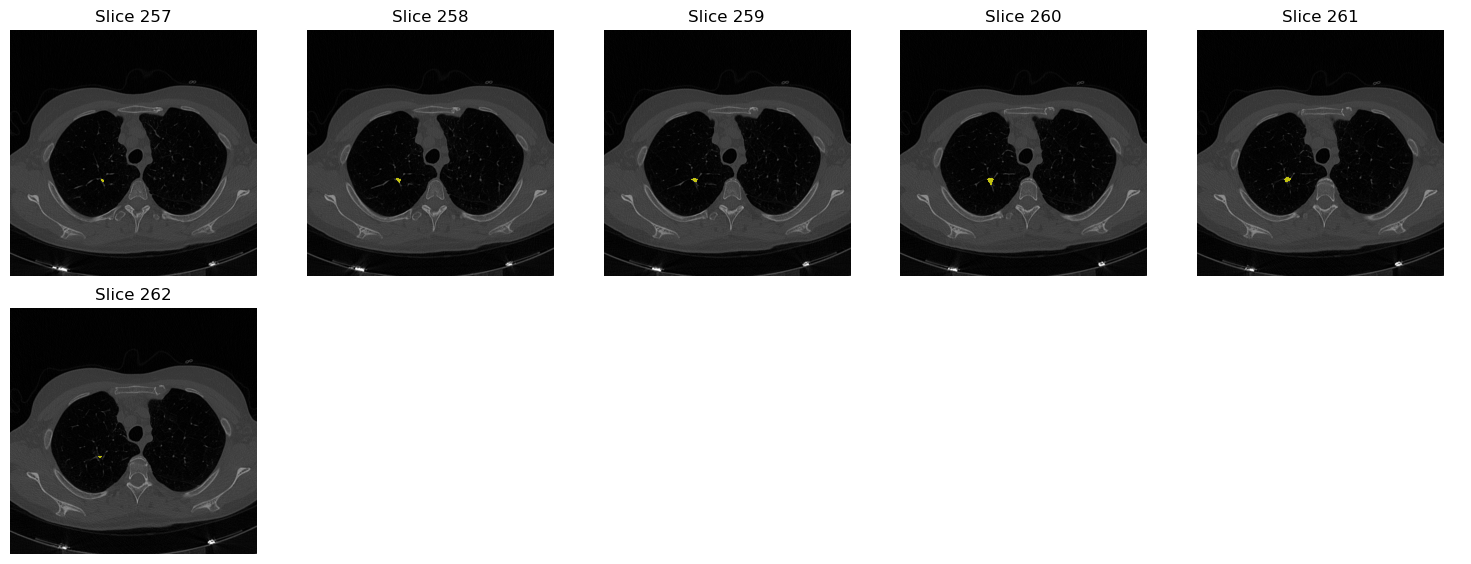

In [11]:
ct_volume = scan["ct_volume"]

for rad in scan["radiologists"]:
    print(f"{'=' * 20} Radiologist {rad['radid']} {'=' * 20}")

    show_ct_mask_overlay(
        ct_volume=ct_volume,
        mask_volume=rad["mask_nodule"],
        slices=rad["nodule_slices"],
    )

# Compute Bounding Box

In [12]:
def compute_bounding_boxes(scan):
    """
    Compute the axis-aligned bounding box for each radiologist's binary mask.
    """

    radiologists = []

    for rad in scan["radiologists"]:
        # Retrieve the binary mask
        binary_mask = rad["mask_nodule"]

        # Find the coordinates of all foreground voxels
        coords = np.argwhere(binary_mask)

        # Ensure the mask contains at least one foreground voxel
        if coords.size == 0:
            raise ValueError(
                f"Empty binary mask found for radiologist {rad['radid']}."
            )

        # Compute the minimum and maximum coordinates
        zmin, ymin, xmin = coords.min(axis=0)
        zmax, ymax, xmax = coords.max(axis=0)

        # Store the bounding box together with the radiologist information
        radiologists.append({
            **rad,
            "bbox": {
                "xmin": int(xmin),
                "xmax": int(xmax),

                "ymin": int(ymin),
                "ymax": int(ymax),

                "zmin": int(zmin),
                "zmax": int(zmax),
            }

        })

    return {
        **scan,
        "radiologists": radiologists
    }

In [13]:
scan = compute_bounding_boxes(scan)

==================== Radiologist 1 ====================


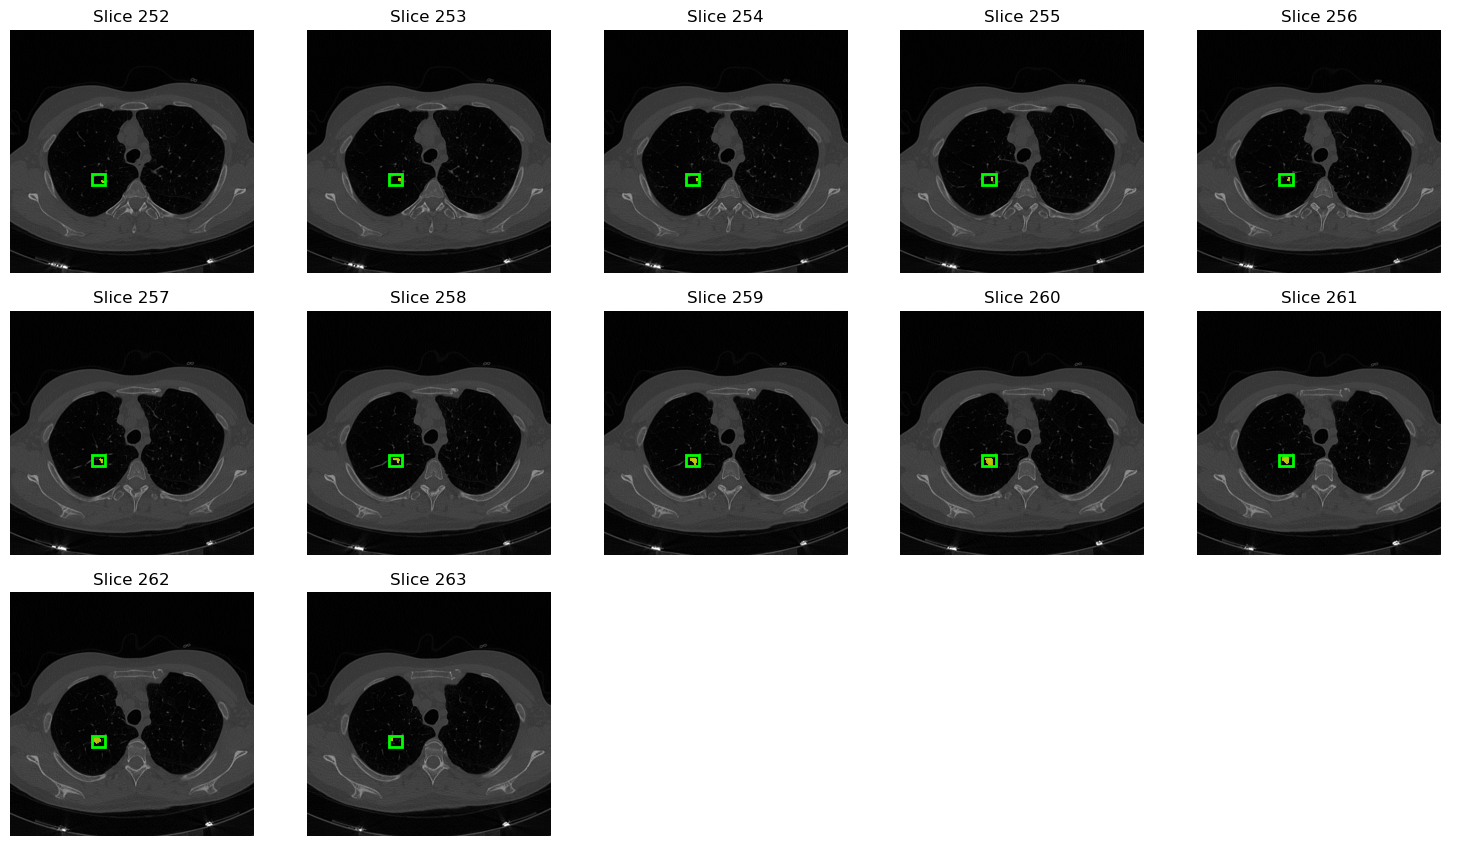

==================== Radiologist 2 ====================


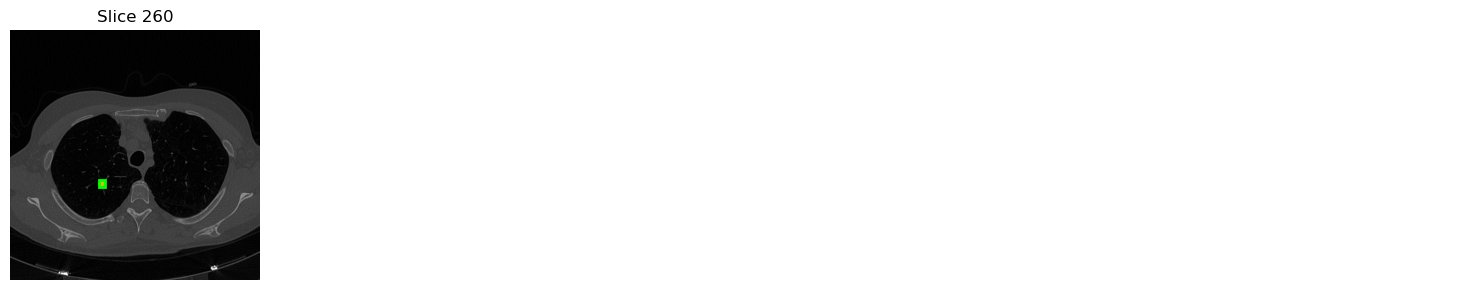

==================== Radiologist 3 ====================


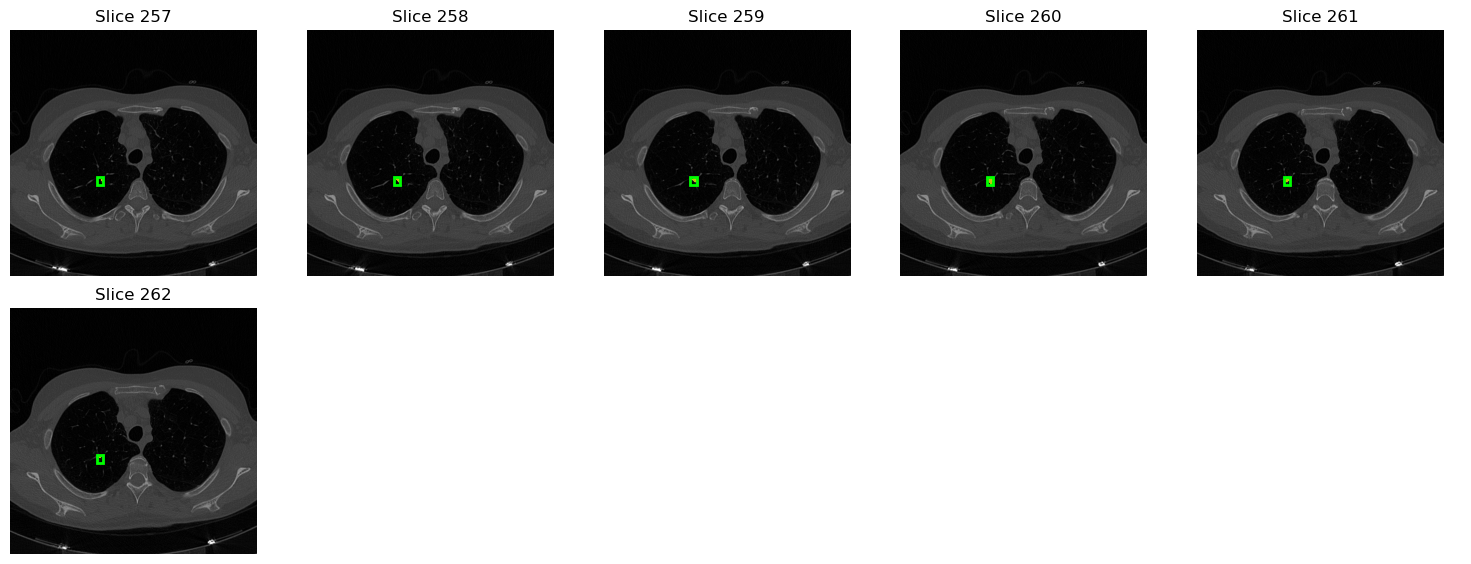

In [14]:
ct_volume = scan["ct_volume"]

for rad in scan["radiologists"]:
    print(f"{'=' * 20} Radiologist {rad['radid']} {'=' * 20}")

    show_ct_mask_overlay(
        ct_volume=ct_volume,
        mask_volume=rad["mask_nodule"],
        slices=rad["nodule_slices"],
        bbox=rad["bbox"],
    )

# Compute Consensus Bounding Box

In [15]:
def compute_consensus_bounding_box(scan):
    """
    Compute a bounding box that encloses all radiologist annotations.
    """

    radiologists = scan["radiologists"]

    consensus_bbox = {
        "xmin": min(rad["bbox"]["xmin"] for rad in radiologists),
        "xmax": max(rad["bbox"]["xmax"] for rad in radiologists),

        "ymin": min(rad["bbox"]["ymin"] for rad in radiologists),
        "ymax": max(rad["bbox"]["ymax"] for rad in radiologists),

        "zmin": min(rad["bbox"]["zmin"] for rad in radiologists),
        "zmax": max(rad["bbox"]["zmax"] for rad in radiologists),
    }

    return {
        **scan,
        "consensus_bbox": consensus_bbox
    }

In [16]:
scan = compute_consensus_bounding_box(scan)

In [17]:
def show_consensus_bbox(scan):
    """
    Display one CT slice that is annotated by every radiologist together with
    each radiologist's bounding box and the consensus bounding box.
    """

    ct_volume = scan["ct_volume"]
    radiologists = scan["radiologists"]
    consensus_bbox = scan["consensus_bbox"]

    # Find slices annotated by every radiologist.
    common_slices = sorted(
        set(radiologists[0]["nodule_slices"]).intersection(
            *[set(rad["nodule_slices"]) for rad in radiologists[1:]]
        )
    )

    if len(common_slices) == 0:
        print("No common slice found.")
        return

    # Select the middle slice.
    slice_idx = common_slices[len(common_slices) // 2]

    colors = ["red", "lime", "cyan", "yellow", "magenta"]

    fig, ax = plt.subplots(figsize=(7, 7))

    # Display CT slice.
    ax.imshow(ct_volume[slice_idx], cmap="gray")

    legend_handles = []

    # Draw each radiologist's bounding box.
    for i, rad in enumerate(radiologists):
        bbox = rad.get("bbox")

        if bbox is None:
            continue

        rect = Rectangle(
            (bbox["xmin"], bbox["ymin"]),
            bbox["xmax"] - bbox["xmin"],
            bbox["ymax"] - bbox["ymin"],
            linewidth=2,
            edgecolor=colors[i],
            facecolor="none",
        )

        ax.add_patch(rect)

        legend_handles.append(
            Line2D(
                [0],
                [0],
                color=colors[i],
                lw=2,
                label=f"Radiologist {rad['radid']}",
            )
        )

    # Draw consensus bounding box.
    if consensus_bbox is not None:
        rect = Rectangle(
            (consensus_bbox["xmin"], consensus_bbox["ymin"]),
            consensus_bbox["xmax"] - consensus_bbox["xmin"],
            consensus_bbox["ymax"] - consensus_bbox["ymin"],
            linewidth=3,
            edgecolor="white",
            linestyle="--",
            facecolor="none",
        )

        ax.add_patch(rect)

        legend_handles.append(
            Line2D(
                [0],
                [0],
                color="white",
                lw=3,
                linestyle="--",
                label="Consensus",
            )
        )

    ax.set_title(f"Slice {slice_idx}")
    ax.axis("off")

    ax.legend(
        handles=legend_handles,
        loc="upper right",
        fontsize=10,
    )

    plt.tight_layout()
    plt.show()

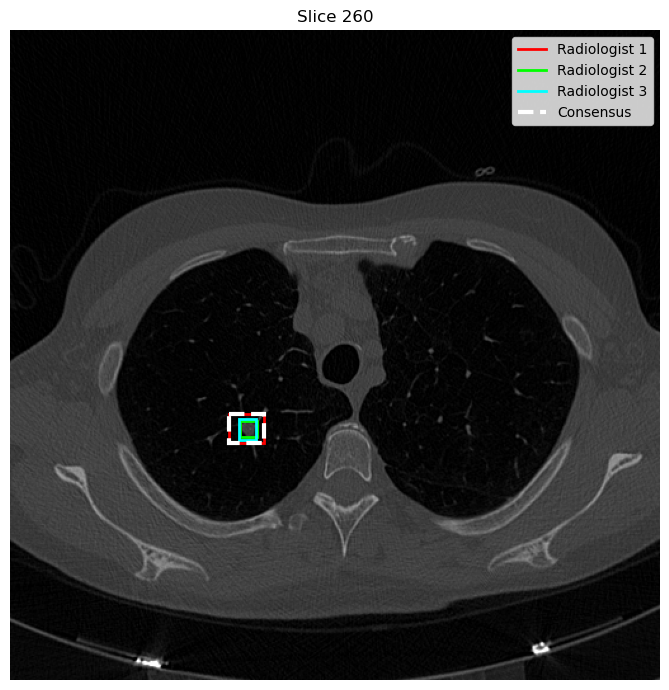

In [18]:
show_consensus_bbox(scan)

# Crop CT and Masks

In [19]:
def crop_scan(scan):
    """
    Crop the CT volume and all binary masks using the consensus
    bounding box while preserving the crop origin.
    """

    bbox = scan["consensus_bbox"]

    zmin, zmax = bbox["zmin"], bbox["zmax"]
    ymin, ymax = bbox["ymin"], bbox["ymax"]
    xmin, xmax = bbox["xmin"], bbox["xmax"]

    # Crop CT volume
    ct_crop = scan["ct_volume"][
        zmin:zmax + 1,
        ymin:ymax + 1,
        xmin:xmax + 1,
    ]

    # Crop every radiologist mask
    radiologists = []

    for rad in scan["radiologists"]:
        mask_crop = rad["mask_nodule"][
            zmin:zmax + 1,
            ymin:ymax + 1,
            xmin:xmax + 1,
        ]

        radiologists.append({
            **rad,
            "mask_crop": mask_crop,
        })

    return {
        **scan,
        "ct_crop": ct_crop,

        # Save crop origin in the original CT coordinates
        "crop_origin": {
            "z": zmin,
            "y": ymin,
            "x": xmin,
        },

        "radiologists": radiologists,
    }

In [20]:
scan = crop_scan(scan)

# Stack Binary Mask

In [21]:
def stack_masks(scan):
    """
    Stack all cropped binary masks into a single 4D array.
    """

    # Stack cropped binary masks from all radiologists
    mask_stack = np.stack(
        [rad["mask_crop"] for rad in scan["radiologists"]],
        axis=0
    )

    return {
        **scan,
        "mask_stack": mask_stack
    }

In [22]:
scan = stack_masks(scan)

# Compute Agreement Mask

In [ ]:
def compute_agreement_map(scan):
    """
    Compute the voxel-wise agreement map from the stacked binary masks.
    """

    # Count how many radiologists annotated each voxel
    agreement_map = np.sum(scan["mask_stack"], axis=0)

    return {
        **scan,
        "agreement_map": agreement_map
    }

In [24]:
scan = compute_agreement_map(scan)

In [ ]:
def show_agreement_map(
    scan,
    slices=None,
    alpha=0.6,
    n_columns=5,
    figsize_per_subplot=3,
):
    """
    Display the cropped CT slices with the agreement map overlay.
    """

    ct_crop = scan["ct_crop"]
    agreement_map = scan["agreement_map"]

    num_radiologists = len(scan["radiologists"])

    # Original z-index of the cropped volume
    slice_offset = scan["crop_origin"]["z"]

    # Automatically select slices containing agreement voxels
    if slices is None:
        slices = np.where(
            np.any(agreement_map > 0, axis=(1, 2))
        )[0]

    if len(slices) == 0:
        print("No agreement voxels found.")
        return

    # Discrete colormap
    colors = [
        "#4DB6AC",  # Agreement = 1
        "#FFD54F",  # Agreement = 2
        "#D32F2F",  # Agreement = 3
        "#7B1FA2",  # Agreement = 4
    ]

    cmap = ListedColormap(colors[:num_radiologists])

    bounds = np.arange(0.5, num_radiologists + 1.5, 1)
    norm = BoundaryNorm(bounds, cmap.N)

    n_rows = math.ceil(len(slices) / n_columns)

    fig, axes = plt.subplots(
        n_rows,
        n_columns,
        figsize=(
            n_columns * figsize_per_subplot,
            n_rows * figsize_per_subplot,
        ),
    )

    axes = np.atleast_1d(axes).flatten()

    im = None

    for ax, z in zip(axes, slices):
        # CT crop
        ax.imshow(
            ct_crop[z],
            cmap="gray",
            interpolation="none",
        )

        # Agreement map
        im = ax.imshow(
            np.ma.masked_where(
                agreement_map[z] == 0,
                agreement_map[z],
            ),
            cmap=cmap,
            norm=norm,
            alpha=alpha,
            interpolation="none",
        )

        # Display original slice number
        ax.set_title(f"Slice {z + slice_offset}")
        ax.axis("off")

    # Hide unused axes
    for ax in axes[len(slices):]:
        ax.axis("off")

    fig.subplots_adjust(
        right=0.90,
        wspace=0.08,
        hspace=0.20,
    )

    cbar = fig.colorbar(
        im,
        ax=axes.tolist(),
        ticks=np.arange(1, num_radiologists + 1),
        fraction=0.035,
        pad=0.02,
    )

    cbar.set_label("Agreement Level")

    cbar.set_ticklabels(
        [
            f"{i} Radiologist" if i == 1 else f"{i} Radiologists"
            for i in range(1, num_radiologists + 1)
        ]
    )

    plt.show()

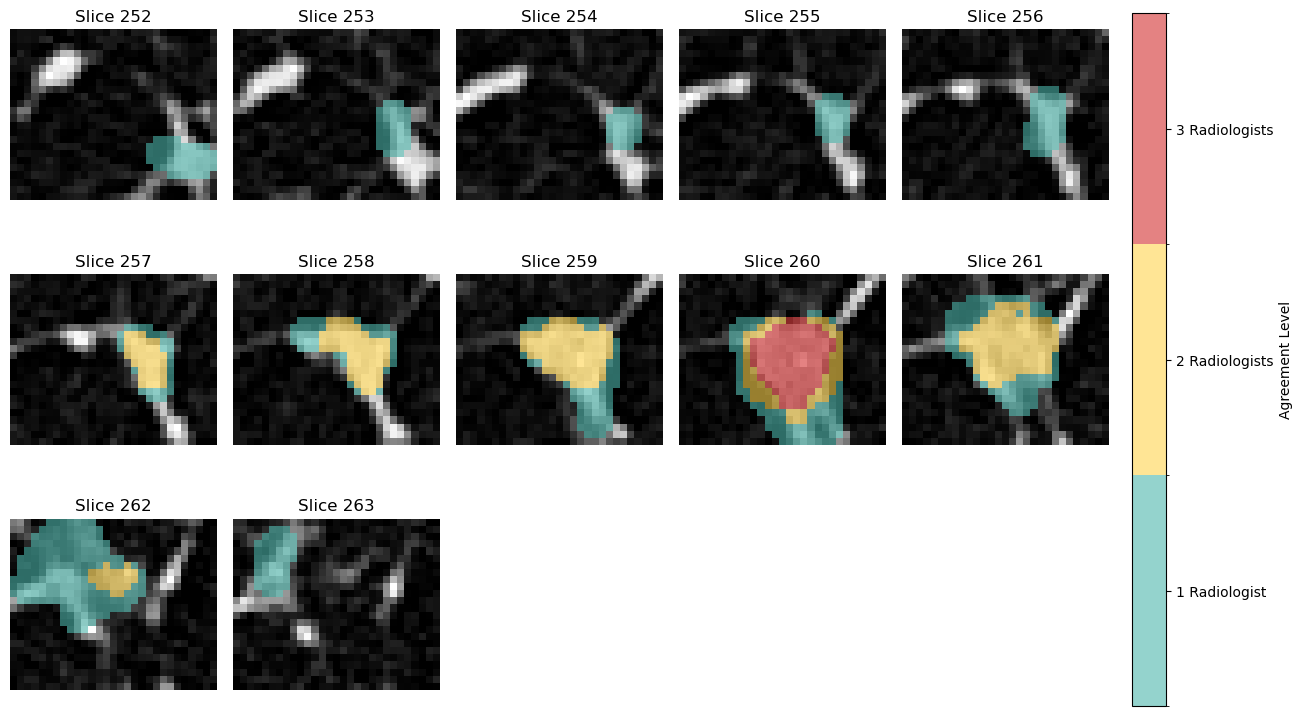

In [26]:
show_agreement_map(scan)

# Consensus

In [27]:
def create_consensus_mask(scan, clevel=0.5):

    agreement_map = scan["agreement_map"]
    num_radiologists = len(scan["radiologists"])

    threshold = math.ceil(clevel * num_radiologists)

    consensus_mask = agreement_map >= threshold

    return {
        **scan,
        "clevel": clevel,
        "consensus_threshold": threshold,
        "consensus_mask": consensus_mask,
    }

In [28]:
scan = create_consensus_mask(scan, clevel=0.5) 

In [29]:
def show_consensus_mask(
    scan,
    slices=None,
    alpha=0.5,
    n_columns=5,
    figsize_per_subplot=3,
):
    """
    Display the cropped CT slices with the consensus mask overlay.
    """

    ct_crop = scan["ct_crop"]
    consensus_mask = scan["consensus_mask"]

    # Original z-index of the cropped volume
    slice_offset = scan["crop_origin"]["z"]

    # Automatically select slices containing consensus voxels
    if slices is None:
        slices = np.where(
            np.any(consensus_mask, axis=(1, 2))
        )[0]

    if len(slices) == 0:
        print("No consensus voxels found.")
        return

    n_rows = math.ceil(len(slices) / n_columns)

    fig, axes = plt.subplots(
        n_rows,
        n_columns,
        figsize=(
            n_columns * figsize_per_subplot,
            n_rows * figsize_per_subplot,
        ),
    )

    axes = np.atleast_1d(axes).flatten()

    for ax, z in zip(axes, slices):

        # CT crop
        ax.imshow(
            ct_crop[z],
            cmap="gray",
            interpolation="none",
        )

        # Consensus mask
        ax.imshow(
            np.ma.masked_where(
                consensus_mask[z] == 0,
                consensus_mask[z],
            ),
            cmap="spring",
            alpha=alpha,
            interpolation="none",
        )

        # Display original slice number
        ax.set_title(f"Slice {z + slice_offset}")
        ax.axis("off")

    # Hide unused axes
    for ax in axes[len(slices):]:
        ax.axis("off")

    fig.suptitle(
        "Consensus Mask",
        fontsize=14,
    )

    fig.subplots_adjust(
        top=0.90,
        wspace=0.10,
        hspace=0.25,
    )

    plt.show()

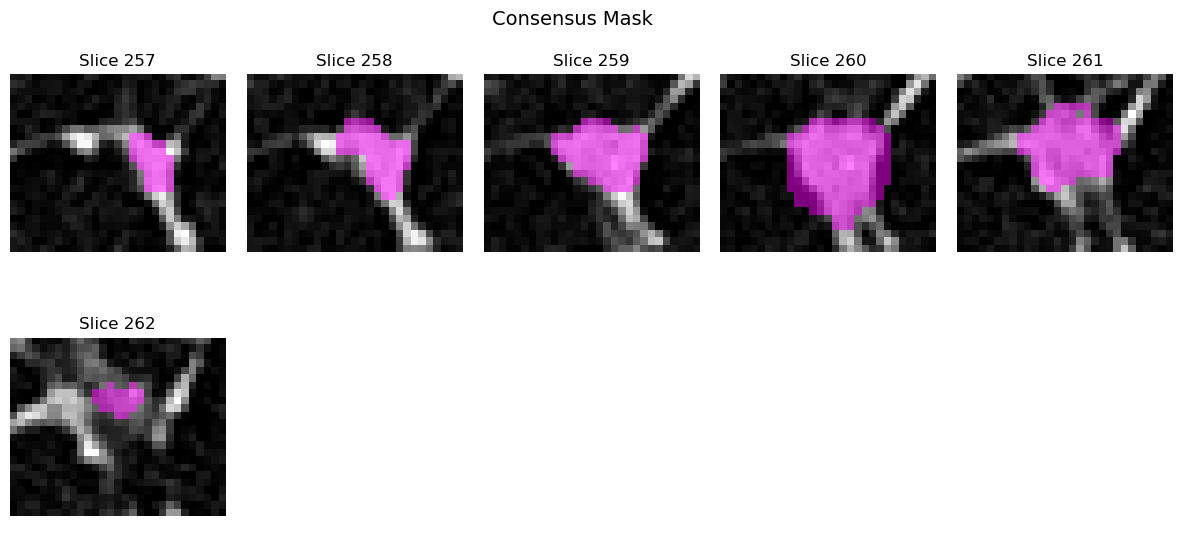

In [30]:
show_consensus_mask(scan)

# Restore Consensus Mask

In [31]:
def restore_consensus_mask(scan):
    """
    Restore the cropped consensus mask to the original CT volume size.
    """

    # Create an empty mask with the same shape as the CT volume
    consensus_mask_full = np.zeros_like(
        scan["ct_volume"],
        dtype=scan["consensus_mask"].dtype
    )

    # Retrieve the consensus bounding box
    bbox = scan["consensus_bbox"]

    zmin, zmax = bbox["zmin"], bbox["zmax"]
    ymin, ymax = bbox["ymin"], bbox["ymax"]
    xmin, xmax = bbox["xmin"], bbox["xmax"]

    # Insert the cropped consensus mask into the original volume
    consensus_mask_full[
        zmin:zmax + 1,
        ymin:ymax + 1,
        xmin:xmax + 1
    ] = scan["consensus_mask"]

    return {
        **scan,
        "consensus_mask_full": consensus_mask_full
    }

In [32]:
scan = restore_consensus_mask(scan)

In [33]:
def show_restored_consensus_mask(
    scan,
    slices=None,
    alpha=0.5,
    n_columns=5,
    figsize_per_subplot=3,
):
    """
    Display the restored consensus mask overlaid on the original CT volume.
    """

    ct_volume = scan["ct_volume"]
    consensus_mask = scan["consensus_mask_full"]

    # Automatically select slices containing consensus voxels
    if slices is None:
        slices = np.where(
            np.any(consensus_mask, axis=(1, 2))
        )[0]

    if len(slices) == 0:
        print("No consensus voxels found.")
        return

    n_rows = math.ceil(len(slices) / n_columns)

    fig, axes = plt.subplots(
        n_rows,
        n_columns,
        figsize=(
            n_columns * figsize_per_subplot,
            n_rows * figsize_per_subplot,
        ),
    )

    axes = np.atleast_1d(axes).flatten()

    for ax, z in zip(axes, slices):
        # Original CT
        ax.imshow(
            ct_volume[z],
            cmap="gray",
        )

        # Restored consensus mask
        ax.imshow(
            np.ma.masked_where(
                consensus_mask[z] == 0,
                consensus_mask[z],
            ),
            cmap="spring",
            alpha=alpha,
            interpolation="none",
            vmin=0,
            vmax=1,
        )

        ax.set_title(f"Slice {z}")
        ax.axis("off")

    # Hide unused axes
    for ax in axes[len(slices):]:
        ax.axis("off")

    fig.suptitle(
        "Restored Consensus Mask",
        fontsize=14,
    )

    fig.subplots_adjust(
        top=0.90,
        wspace=0.10,
        hspace=0.25,
    )

    plt.show()

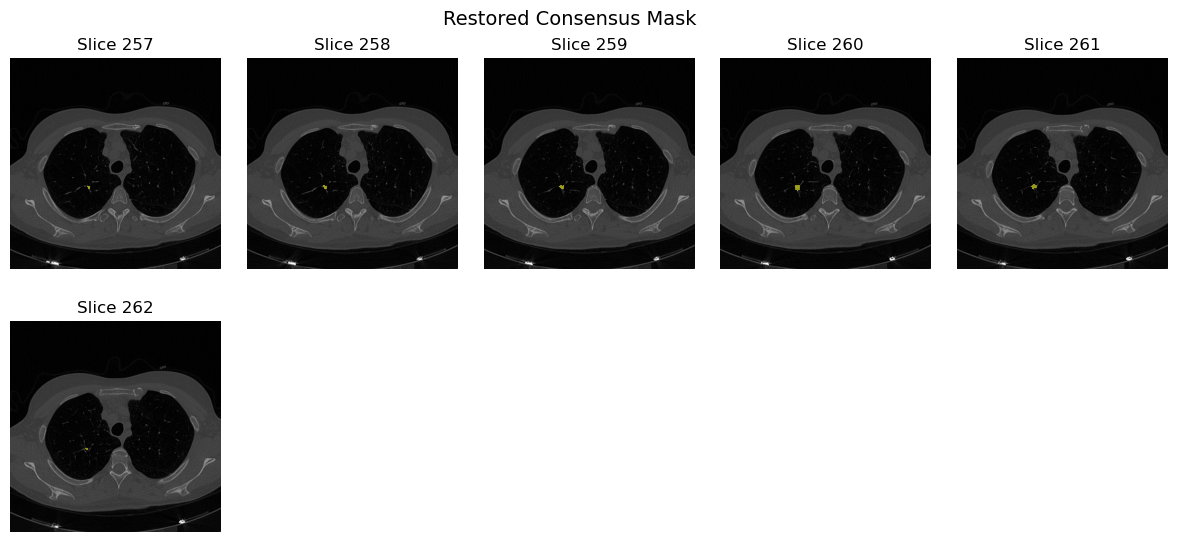

In [34]:
show_restored_consensus_mask(scan)